In [13]:
import pandas as pd
import pyrsm as rsm

In [14]:
data = pd.read_stata('karlan_list_2007.dta')
data.head()

,treatment,control,ratio,ratio2,ratio3,size,size25,size50,size100,sizeno,...,redcty,bluecty,pwhite,pblack,page18_39,ave_hh_sz,median_hhincome,powner,psch_atlstba,pop_propurban
0,0,1,Control,0,0,Control,0,0,0,0,...,0.0,1.0,0.446493,0.527769,0.317591,2.10,28517.0,0.499807,0.324528,1.0
1,0,1,Control,0,0,Control,0,0,0,0,...,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,1,0,0,"$100,000",0,0,1,0,...,0.0,1.0,0.935706,0.011948,0.276128,2.48,51175.0,0.721941,0.192668,1.0
3,1,0,1,0,0,Unstated,0,0,0,1,...,1.0,0.0,0.888331,0.010760,0.279412,2.65,79269.0,0.920431,0.412142,1.0
4,1,0,1,0,0,"$50,000",0,1,0,0,...,0.0,1.0,0.759014,0.127421,0.442389,1.85,40908.0,0.416072,0.439965,1.0


In [15]:
a=data.describe().round(2)
a

,treatment,control,ratio2,ratio3,size25,size50,size100,sizeno,askd1,askd2,...,redcty,bluecty,pwhite,pblack,page18_39,ave_hh_sz,median_hhincome,powner,psch_atlstba,pop_propurban
count,50083.00,50083.00,50083.00,50083.00,50083.00,50083.00,50083.00,50083.00,50083.00,50083.00,...,49978.00,49978.00,48217.00,48047.00,48217.00,48221.00,48209.00,48214.00,48215.00,48217.00
mean,0.67,0.33,0.22,0.22,0.17,0.17,0.17,0.17,0.22,0.22,...,0.51,0.49,0.82,0.09,0.32,2.43,54815.70,0.67,0.39,0.87
std,0.47,0.47,0.42,0.42,0.37,0.37,0.37,0.37,0.42,0.42,...,0.50,0.50,0.17,0.14,0.10,0.38,22027.32,0.19,0.19,0.26
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.01,0.00,0.00,0.00,5000.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.76,0.01,0.26,2.21,39181.00,0.56,0.24,0.88
50%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.87,0.04,0.31,2.44,50673.00,0.71,0.37,1.00
75%,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,0.94,0.09,0.37,2.66,66005.00,0.82,0.53,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,0.99,1.00,5.27,200001.00,1.00,1.00,1.00


In [16]:
data['treat'] = rsm.ifelse(data.treatment == 0, 'control', 'treatment')
no_month = rsm.basics.compare_means({"data": data}, var1="treat", var2="mrm2", alt_hyp="two-sided")
no_month.summary(extra=True)

Pairwise mean comparisons (t-test)
Data      : data
Variables : treat, mrm2
Samples   : independent
Confidence: 0.95
Adjustment: None
    treat   mean     n  n_missing     sd    se    me
  control 12.998 16687          0 12.074 0.093 0.183
treatment 13.012 33395          1 12.086 0.066 0.130
          Null hyp.                      Alt. hyp.   diff p.value    se  t.value        df   2.5%  97.5%  
control = treatment control not equal to treatment -0.014   0.905 0.114    -0.12 33394.142 -0.238  0.211  

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [17]:
import matplotlib.pyplot as plt

donate_rate = data.groupby("treatment")["gave"].mean().reset_index()
donate_rate["group"] = donate_rate["treatment"].map({0: "Control", 1: "Treatment"})
donate_rate

,treatment,gave,group
0,0,0.017858,Control
1,1,0.022039,Treatment


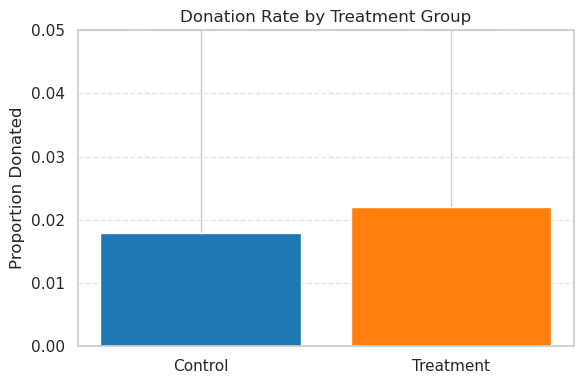

In [18]:
donate_rate["group"] = donate_rate["treatment"].map({0: "Control", 1: "Treatment"})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(donate_rate["group"], donate_rate["gave"], color=["#1f77b4", "#ff7f0e"])
ax.set_ylabel("Proportion Donated")
ax.set_title("Donation Rate by Treatment Group")
ax.set_ylim(0, 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_32420/418144370.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


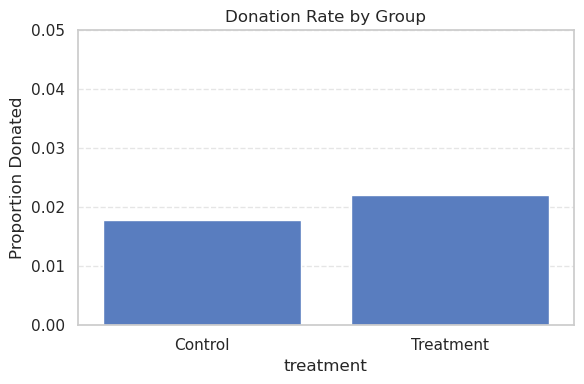

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置风格
sns.set(style="whitegrid", palette="muted")

# 创建图像
plt.figure(figsize=(6, 4))
sns.barplot(
    data=data,
    x="treatment",
    y="gave",
    ci=None
)

# 添加标签和标题
plt.xticks([0, 1], ["Control", "Treatment"])
plt.ylabel("Proportion Donated")
plt.title("Donation Rate by Group")
plt.ylim(0, 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
?rsm.model.regress.summary

Signature:
rsm.model.regress.summary(
    self,
    main=True,
    fit=True,
    ci=False,
    ssq=False,
    rmse=False,
    vif=False,
    test: Optional[str] = None,
    dec: int = 3,
) -> None
Docstring:
Summarize the linear regression model output

Parameters
----------
main : bool, default True
    Print the main summary. Can be useful to turn off (i.e., False) when the focus is on other metrics (e.g., VIF).
fit : bool, default True
    Print the fit statistics. Can be useful to turn off (i.e., False) when the focus is on other metrics (e.g., VIF).
ci : bool, default False
    Print the confidence intervals for the coefficients.
ssq : bool, default False
    Print the sum of squares.
rmse : bool, default False
    Print the root mean square error.
vif : bool, default False
    Print the generalized variance inflation factors.
test : list[str] or None, optional
    List of variable names used in the model to test using a Chi-Square test or None if no tests are performed.
dec : int

In [24]:
data_2_1 = data[data["ratio"].isin([1, 2])].copy()

data_2_1["ratio"] = pd.Categorical(data_2_1["ratio"].astype(str))

dif_2_1 = rsm.basics.compare_means({"data": data_2_1}, var1="ratio", var2="gave", alt_hyp="two-sided")
dif_2_1.summary(extra=True)

Pairwise mean comparisons (t-test)
Data      : data
Variables : ratio, gave
Samples   : independent
Confidence: 0.95
Adjustment: None
ratio  mean     n  n_missing    sd    se    me
    1 0.021 11133          0 0.143 0.001 0.003
    2 0.023 11134          0 0.149 0.001 0.003
Null hyp.        Alt. hyp.   diff p.value    se  t.value        df   2.5%  97.5%  
    1 = 2 1 not equal to 2 -0.002   0.335 0.002   -0.965 22225.078 -0.006  0.002  

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [26]:
# 筛选 1:1, 2:1, 3:1 的处理组
data_1_2_3 = data[data["ratio"].isin([1, 2, 3])].copy()

# 正确转换为字符串型 category
data_1_2_3["ratio"] = pd.Categorical(data_1_2_3["ratio"].astype(str))

# 回归
lr = rsm.model.regress({'data': data_1_2_3}, rvar='gave', evar='ratio')
lr.summary()

Linear regression (OLS)
Data                 : data
Response variable    : gave
Explanatory variables: ratio
Null hyp.: the effect of x on gave is zero
Alt. hyp.: the effect of x on gave is not zero

           coefficient  std.error  t.value p.value     
Intercept        0.021      0.001   14.912  < .001  ***
ratio[2]         0.002      0.002    0.958   0.338     
ratio[3]         0.002      0.002    1.008   0.313     

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.0, Adjusted R-squared: -0.0
F-statistic: 0.645 df(2, 33393), p.value 0.524
Nr obs: 33,396
